# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn
import scipy
from torch.autograd import Variable
from torchinfo import summary
from tqdm import tqdm
from sklearn.metrics import r2_score


# Select device

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


# Problem Setup

# Load data and extract variables

In [3]:
data = scipy.io.loadmat("data.mat")
x = data['x'] # x coordinates data/ nodes for training
f_fun = data['f'] # body source data
u_data = data['u'] # solution data

# data = scipy.io.loadmat("data_noise.mat")
# x = data['x']
# f_fun = data['f']
# u_data = data['u_noise']
# u_data[0] = 0
# u_data[-1] = 0

In [4]:
a = x[0,0] #start node
b = x[-1,0] #end node
Ne = x.shape[0]-1 #elements

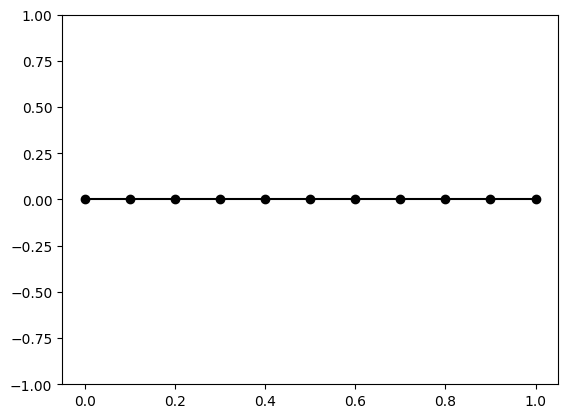

In [5]:
x_pred = np.arange(0,b+(b-a)/100,1/100).reshape(-1,1) # x coordinates for figure/ nodes for prediction
y = x*0

plt.figure()
plt.plot(x,y,'-k')
plt.plot(x,y,'ok')
plt.ylim([-1, 1])
plt.show()

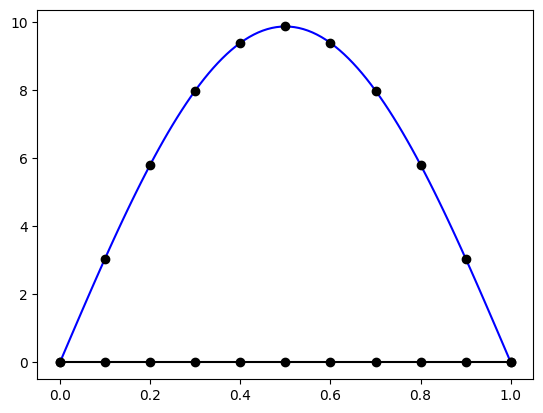

In [6]:
f_fun_fig = math.pi**2*np.sin(math.pi*x_pred) # body source for figure

plt.figure()
plt.plot(x,y,'-k')
plt.plot(x,y,'ok')
plt.plot(x_pred,f_fun_fig,'-b')
plt.plot(x,f_fun,'ok')
plt.show()

# Create Neural Net for training

# Activation function

In [7]:
class Tanh(nn.Module):
    def forward(self, x):
        return torch.tanh(x)

# Neural net definition

In [8]:
class create_net(nn.Module):
    def __init__(self):
        super(create_net, self).__init__()
        self.hidden_layer1 = nn.Linear(1,50)
        self.hidden_layer2 = nn.Linear(50,50)
        self.output_layer = nn.Linear(50,1)
        self.activation = Tanh()

    def forward(self, x):
        inputs = x
        layer1_out = self.hidden_layer1(inputs)
        layer1_out = self.activation(layer1_out)
        layer2_out = self.hidden_layer2(layer1_out)
        layer2_out = self.activation(layer2_out)     
        output = self.output_layer(layer2_out)
        return output

# Generate model

In [9]:
model = create_net()
model = model.to(device)
summary(model, x.shape)

Layer (type:depth-idx)                   Output Shape              Param #
create_net                               [11, 1]                   --
├─Linear: 1-1                            [11, 50]                  100
├─Tanh: 1-2                              [11, 50]                  --
├─Linear: 1-3                            [11, 50]                  2,550
├─Tanh: 1-4                              [11, 50]                  --
├─Linear: 1-5                            [11, 1]                   51
Total params: 2,701
Trainable params: 2,701
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.03
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.01
Estimated Total Size (MB): 0.02

# Create Loss Function for training

# Convert variables to tensors for training

In [10]:
x_ode = Variable(torch.from_numpy(x).float(), requires_grad=True).to(device)
f_fun_ode = Variable(torch.from_numpy(f_fun).float(), requires_grad=True).to(device)
u_data_ode = Variable(torch.from_numpy(u_data).float(), requires_grad=True).to(device)

# Loss function definition

In [11]:
def loss(x, model, u_data):
        
    u_pred = model(x)
    
    loss = torch.nn.MSELoss()

    total_loss = loss(u_pred, u_data)

    return total_loss

# Training step

# Select number of epochs (iterations) and optimizer

In [12]:
epochs = 1000
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)
pbar = tqdm(range(epochs), desc='description')

description:   0%|          | 0/1000 [00:00<?, ?it/s]

# Back propagation definition

In [13]:
def closure():
    if torch.is_grad_enabled():
        optimizer.zero_grad()
    
    total_loss = loss(x_ode, model, u_data_ode)
    
    if total_loss.requires_grad:
        total_loss.backward()
    
    return total_loss

# Run training

In [14]:
for i in pbar:
    
    optimizer.step(closure)
    
    total_loss = loss(x_ode, model, u_data_ode)
    
    pbar.set_description("total_loss: %.2e " % (total_loss.cpu().detach().numpy()))

total_loss: 2.35e-06 : 100%|██████████| 1000/1000 [00:01<00:00, 544.61it/s]


# Compare to actual

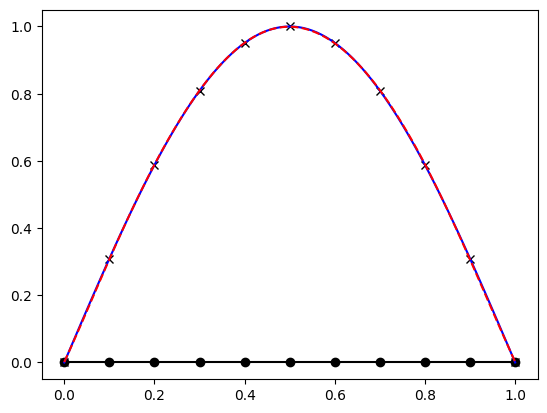

In [15]:
x_pred_ode = Variable(torch.from_numpy(x_pred).float(), requires_grad=True).to(device)

with torch.no_grad():
    u_pred = model(x_pred_ode)
    
u_actual = np.sin(math.pi*x_pred)

plt.figure()
plt.plot(x,y,'-k')
plt.plot(x,y,'ok')
plt.plot(x,u_data,'xk')
plt.plot(x_pred,u_actual,'-b')
plt.plot(x_pred,u_pred.cpu().numpy(),'--r')
plt.show()

In [16]:
r2_score(u_pred.cpu().numpy(), u_actual)

0.9999708613041994